# Tutorial 1: MLP Search on MNIST

Demonstrates global (NSGA-II) + local (QAT + pruning) search for MLP architectures targeting FPGA deployment.

All parameters are controlled via `t1_config.yaml` in this directory.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))

import yaml
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils.tf_global_search import GlobalSearchTF
from utils.tf_local_search_separated import local_search_entrypoint
from utils.tf_data_preprocessing import load_and_preprocess_mnist

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
tf.get_logger().setLevel('ERROR')
print("TensorFlow Version:", tf.__version__)

cfg = yaml.safe_load(open(Path.cwd() / "t1_config.yaml"))
ds_cfg = cfg["dataset"]
s_cfg = cfg["search"]
ss_cfg = cfg["search_space"]
ls_cfg = cfg["local_search"]
out_cfg = cfg["output"]

RESULTS_DIR = out_cfg["results_dir"]
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Results dir: {RESULTS_DIR}")
print(f"n_trials={s_cfg['n_trials']}, epochs={s_cfg['epochs']}, subset_size={ds_cfg['subset_size']}")

2026-02-24 16:52:11.324980: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow Version: 2.15.1
Results dir: ./results/tutorial1_mlp
n_trials=3, epochs=2, subset_size=10000


## Dataset: MNIST

Data loaded and preprocessed:
  Resize: 8x8
  x_train shape: (10000, 8, 8, 1), x_val shape: (10000, 8, 8, 1)
  y_train shape: (10000,), y_val shape: (10000,)


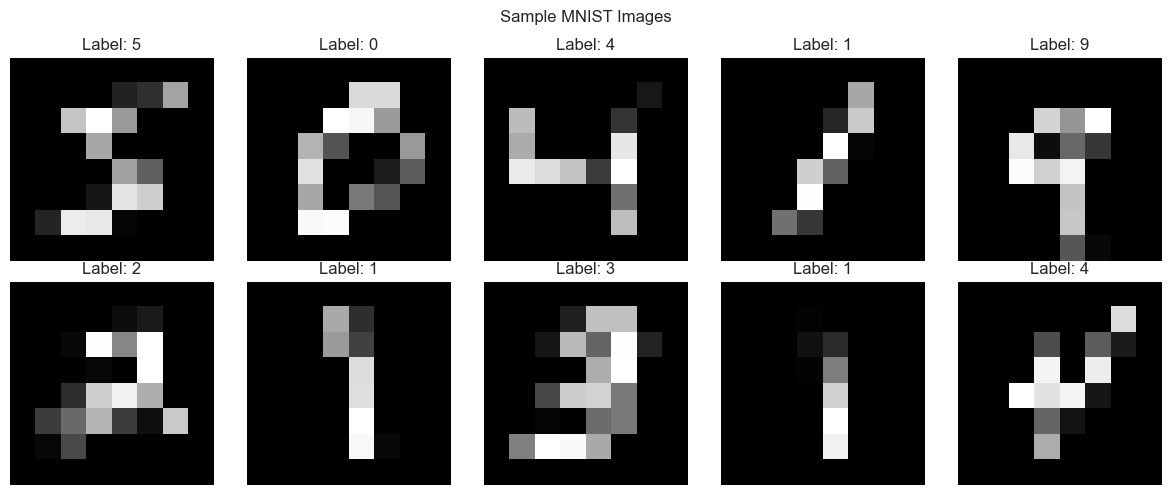

In [2]:
x_train_viz, y_train_viz, _, _ = load_and_preprocess_mnist(
    resize_val=ds_cfg["resize_val"],
    subset_size=ds_cfg["subset_size"],
    flatten=False,
    one_hot=False,
)

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_viz[i].squeeze(), cmap='gray')
    plt.title(f"Label: {y_train_viz[i]}")
    plt.axis('off')
plt.suptitle("Sample MNIST Images")
plt.tight_layout()
plt.show()

## Global Search: Finding the Best Architectural Trade-offs

Runs NSGA-II multi-objective optimization over MLP architectures, optimizing accuracy and BOPs.

In [3]:
obj_names = s_cfg["objective_names"]
max_flags = s_cfg["maximize_flags"]

searcher = GlobalSearchTF(
    search_space_path=ss_cfg,
    results_dir=RESULTS_DIR,
)

study = searcher.run_search(
    model_type=s_cfg["model_type"],
    n_trials=s_cfg["n_trials"],
    epochs=s_cfg["epochs"],
    dataset=ds_cfg["name"],
    subset_size=ds_cfg["subset_size"],
    resize_val=ds_cfg["resize_val"],
    objectives=obj_names,
    maximize_flags=max_flags,
    use_hardware_metrics=s_cfg["use_hardware_metrics"],
)

print("Global Search Complete!")


Starting MLP Global Search on MNIST



[I 2026-02-24 16:52:16,311] A new study created in memory with name: no-name-e51f20b2-6e40-4270-9d55-1da476108d8f


Data loaded and preprocessed:
  Resize: 8x8
  x_train shape: (10000, 64), x_val shape: (10000, 64)
  y_train shape: (10000, 10), y_val shape: (10000, 10)
Using in-memory Optuna study (single-node mode)


[I 2026-02-24 16:52:25,460] Trial 0 finished with values: [0.7944999933242798, 10332352.0, 2.18, 248.01] and parameters: {'num_layers': 2, 'hidden_units1': 128, 'activation1': 'tanh', 'batchnorm1': False}.


Trial 0: Accuracy=0.7945, BOPs=10332352.0


[I 2026-02-24 16:52:27,896] Trial 1 finished with values: [0.6208999752998352, 1292544.0, 0.5925, 73.0] and parameters: {'num_layers': 2, 'hidden_units1': 16, 'activation1': 'tanh', 'batchnorm1': False}.


Trial 1: Accuracy=0.6209, BOPs=1292544.0


[I 2026-02-24 16:52:30,283] Trial 2 finished with values: [0.6007999777793884, 1292544.0, 0.5925, 73.0] and parameters: {'num_layers': 2, 'hidden_units1': 16, 'activation1': 'tanh', 'batchnorm1': False}.


Trial 2: Accuracy=0.6008, BOPs=1292544.0

CSV results saved to ./results/tutorial1_mlp/mlp_search_results.csv (3 trials)

🏆 Best model architecture (Trial 0) saved for local search:
   - Source: ./results/tutorial1_mlp/trial_yamls/trial_0_arch.yaml
   - Destination: ./results/tutorial1_mlp/best_model_for_local_search.yaml
   - Accuracy: 0.7945
2D Pareto fronts plot saved to ./results/tutorial1_mlp/pareto_fronts_2d.png
3D Pareto front plot saved to ./results/tutorial1_mlp/pareto_front_3d.html

BEST TRIALS FOUND BY OPTUNA

Rank 1 (Trial 0):
  Values: {'performance_metric': 0.7944999933242798, 'bops': 10332352.0, 'avg_resource': 2.18, 'clock_cycles': 248.01}
  Params: {'num_layers': 2, 'hidden_units1': 128, 'activation1': 'tanh', 'batchnorm1': False}

Rank 2 (Trial 1):
  Values: {'performance_metric': 0.6208999752998352, 'bops': 1292544.0, 'avg_resource': 0.5925, 'clock_cycles': 73.0}
  Params: {'num_layers': 2, 'hidden_units1': 16, 'activation1': 'tanh', 'batchnorm1': False}
Global Searc

## Analyzing the Global Search Results

In [4]:
results_df = pd.DataFrame(searcher.results)
if not results_df.empty:
    best = results_df.loc[results_df['performance_metric'].idxmax()]
    print(f"Best Trial: {best['trial']}  Accuracy: {best['performance_metric']:.4f}  BOPs: {best['bops']:.2e}")
    print(f"Pareto front plots saved to: {RESULTS_DIR}")
else:
    print("No results to visualize.")

Best Trial: 0  Accuracy: 0.7945  BOPs: 1.03e+07
Pareto front plots saved to: ./results/tutorial1_mlp


## Local Search: Compressing the Best Model

Applies Quantization-Aware Training (QAT) and iterative magnitude pruning to the best architecture found.

In [5]:
LOCAL_RESULTS_DIR = os.path.join(RESULTS_DIR, "local_search_separated")
LOCAL_CONFIG_PATH = os.path.join(RESULTS_DIR, "local_search_config.yaml")
ARCH_YAML_PATH = os.path.join(RESULTS_DIR, "best_model_for_local_search.yaml")

local_search_settings = {
    "pruning_settings": {
        "iterations": ls_cfg["pruning_iterations"],
        "epochs_per_iteration": ls_cfg["pruning_epochs"],
        "pruning_rate": ls_cfg["pruning_rate"],
    },
    "qat_settings": {
        "epochs": ls_cfg["qat_epochs"],
        "precision_pairs": ls_cfg["precision_pairs"],
    },
}
with open(LOCAL_CONFIG_PATH, "w") as f:
    yaml.dump(local_search_settings, f)

x_train, y_train, x_val, y_val = load_and_preprocess_mnist(
    resize_val=ds_cfg["resize_val"],
    subset_size=ds_cfg["subset_size"],
    flatten=True,
    one_hot=True,
)

if os.path.exists(ARCH_YAML_PATH):
    pruning_df, qat_df = local_search_entrypoint(
        architecture_yaml_path=ARCH_YAML_PATH,
        local_search_config_path=LOCAL_CONFIG_PATH,
        dataset=(x_train, y_train, x_val, y_val),
        results_dir=LOCAL_RESULTS_DIR,
    )
else:
    print(f"ERROR: Architecture YAML not found: {ARCH_YAML_PATH}")
    pruning_df, qat_df = pd.DataFrame(), pd.DataFrame()

Data loaded and preprocessed:
  Resize: 8x8
  x_train shape: (10000, 64), x_val shape: (10000, 64)
  y_train shape: (10000, 10), y_val shape: (10000, 10)

 STARTING SEPARATED LOCAL SEARCH STAGE 

-------------------- Starting Pruning-Only Experiment --------------------

Pruning Iteration 1/5 - Target Sparsity: 0.2000
Epoch 1/2
79/79 [==============================] - 2s 4ms/step - loss: 1.6450 - accuracy: 0.5745 - val_loss: 1.1545 - val_accuracy: 0.7367
Epoch 2/2
79/79 [==============================] - 0s 2ms/step - loss: 0.9583 - accuracy: 0.7658 - val_loss: 0.8161 - val_accuracy: 0.7821
  -> Accuracy for sparsity 0.2000: 0.7821

Pruning Iteration 2/5 - Target Sparsity: 0.3600
Epoch 1/2
79/79 [==============================] - 1s 4ms/step - loss: 1.4405 - accuracy: 0.6700 - val_loss: 1.0255 - val_accuracy: 0.7535
Epoch 2/2
79/79 [==============================] - 0s 2ms/step - loss: 0.9396 - accuracy: 0.7697 - val_loss: 0.8252 - val_accuracy: 0.7826
  -> Accuracy for sparsity 0.3600

/opt/miniconda3/envs/snac-pack-refactor/lib/python3.10/site-packages/keras/src/initializers/initializers.py:120: UserWarning:

The initializer GlorotUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.



79/79 [==============================] - 1s 5ms/step - loss: 2.3611 - accuracy: 0.1448 - val_loss: 2.2560 - val_accuracy: 0.1868
Epoch 2/2
79/79 [==============================] - 0s 3ms/step - loss: 2.1812 - accuracy: 0.2293 - val_loss: 2.0795 - val_accuracy: 0.2913
  -> Final accuracy for precision <4,1>: 0.2913

 SEPARATED LOCAL SEARCH COMPLETE 


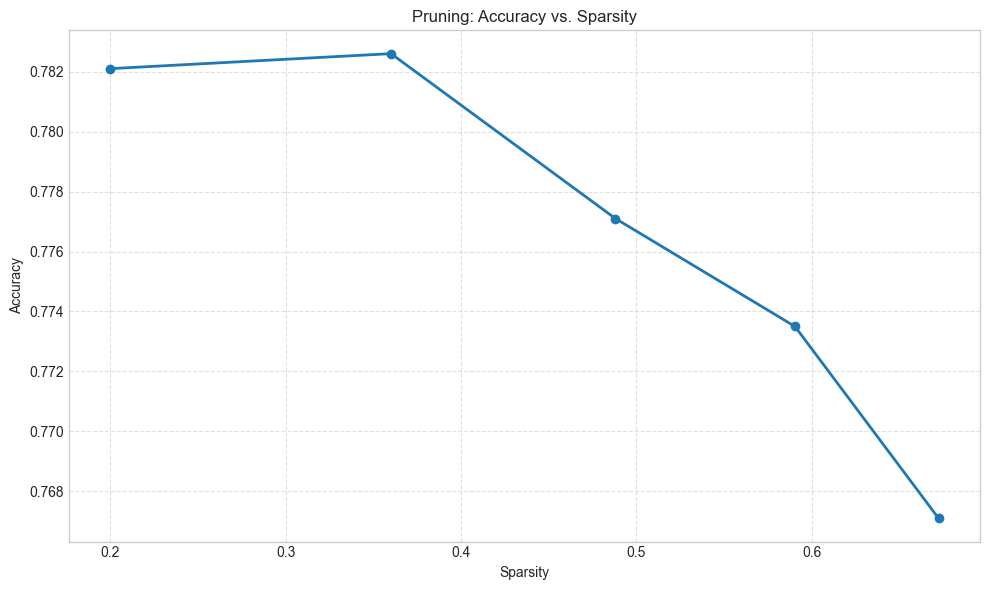

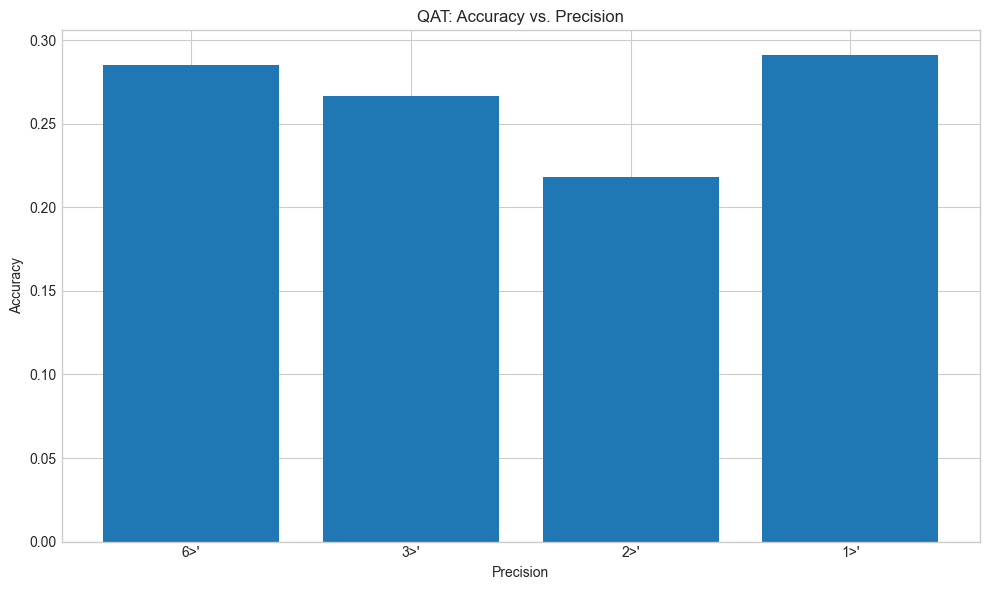

In [6]:
if not pruning_df.empty:
    plt.figure(figsize=(10, 6))
    plt.plot(pruning_df['Sparsity'], pruning_df['Accuracy'], marker='o', linewidth=2)
    plt.title('Pruning: Accuracy vs. Sparsity')
    plt.xlabel('Sparsity')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

if not qat_df.empty:
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(qat_df)), qat_df['Accuracy'], tick_label=qat_df['Precision'])
    plt.title('QAT: Accuracy vs. Precision')
    plt.xlabel('Precision')
    plt.ylabel('Accuracy')
    plt.tight_layout()
    plt.show()